In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

CLUSTER_ORDER = ['Ricchi avanzati', 'Reddito medio-alto',
                 'Reddito basso-medio', 'Poveri estremi']


In [2]:
# Unità di analisi: paese × edizione olimpica
# Per ogni coppia paese-anno abbiamo gli indicatori socioeconomici
# e, per ogni sport, un flag 1 (ha vinto almeno una medaglia) / 0 (non ha vinto)

sport_df  = pd.read_csv('olympics_sport_cluster.csv')
clustered = pd.read_csv('olympics_with_clusters.csv')

INDICATORS = ['gdp_per_capita', 'life_expectancy', 'urbanization_pct',
              'infant_mortality', 'population']

In [3]:
df = sport_df.merge(
    clustered[['noc', 'year'] + INDICATORS],
    left_on=['NOC', 'Year'], right_on=['noc', 'year'], how='left'
)

event_df = (
    df.groupby(['Year', 'NOC', 'Sport', 'Event', 'Medal', 'cluster_label'] + INDICATORS)
    .size().reset_index(name='n')
).dropna(subset=INDICATORS)

In [4]:
country_year = (
    clustered[['noc', 'year', 'cluster_label'] + INDICATORS]
    .dropna(subset=INDICATORS)
    .drop_duplicates(subset=['noc', 'year'])
)
print(f"Paese-anno osservazioni: {len(country_year):,}")


Paese-anno osservazioni: 2,423


In [5]:
sport_counts = event_df['Sport'].value_counts()
SPORTS_OK = sport_counts[sport_counts >= 50].index.tolist()
print(f"Sport analizzati: {len(SPORTS_OK)}")
print(SPORTS_OK)

Sport analizzati: 25
['Athletics', 'Swimming', 'Wrestling', 'Boxing', 'Judo', 'Shooting', 'Canoeing', 'Gymnastics', 'Cycling', 'Rowing', 'Fencing', 'Sailing', 'Weightlifting', 'Diving', 'Equestrianism', 'Taekwondo', 'Archery', 'Table Tennis', 'Tennis', 'Badminton', 'Modern Pentathlon', 'Volleyball', 'Basketball', 'Hockey', 'Synchronized Swimming']


In [6]:
winners_by_sport = (
    event_df[event_df['Sport'].isin(SPORTS_OK)]
    .groupby(['NOC', 'Year', 'Sport'])['n']
    .sum().reset_index()
    .rename(columns={'NOC': 'noc', 'Year': 'year'})
)
winners_by_sport['won'] = 1

In [7]:
imp    = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_base = country_year[INDICATORS].values
X_imp  = imp.fit_transform(X_base)
X_sc   = scaler.fit_transform(X_imp)

print(f"\nFeatures: {INDICATORS}")


Features: ['gdp_per_capita', 'life_expectancy', 'urbanization_pct', 'infant_mortality', 'population']


In [8]:
# Per ogni sport:
#   - y = 1 se il paese ha vinto almeno 1 medaglia in quell'edizione, 0 altrimenti
#   - class_weight='balanced' compensa lo sbilanciamento (pochi vincitori)
#   - AUC-ROC è la metrica principale: misura quanto bene il modello separa
#     vincitori da non vincitori (0.5 = casuale, 1.0 = perfetto)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

In [9]:
for sport in SPORTS_OK:
    # Costruisci y per questo sport
    w = winners_by_sport[winners_by_sport['Sport'] == sport][['noc', 'year', 'won']]
    merged = country_year[['noc', 'year']].merge(w, on=['noc', 'year'], how='left')
    y = merged['won'].fillna(0).astype(int).values

    # Fit
    model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        class_weight='balanced',  # gestisce lo sbilanciamento delle classi
        random_state=42
    )

    # AUC-ROC in cross-validation
    auc_scores = cross_val_score(model, X_sc, y, cv=cv, scoring='roc_auc')

    # Fit su tutti i dati per estrarre coefficienti
    model.fit(X_sc, y)
    coefs = dict(zip(INDICATORS, model.coef_[0]))

    results.append({
        'sport':          sport,
        'n_winners':      y.sum(),
        'pct_winners':    y.mean() * 100,
        'auc_mean':       auc_scores.mean(),
        'auc_std':        auc_scores.std(),
        **{f'coef_{k}': v for k, v in coefs.items()}
    })

In [10]:
results_df = pd.DataFrame(results).sort_values('auc_mean', ascending=False)

In [12]:
print("=== AUC-ROC PER SPORT (ordinato dal più predittivo) ===")
print(f"{'Sport':<25} {'AUC':>6} {'±':>5} {'Vincitori':>10}")

=== AUC-ROC PER SPORT (ordinato dal più predittivo) ===
Sport                        AUC     ±  Vincitori


In [13]:
for _, row in results_df.iterrows():
    bar = '█' * int(row['auc_mean'] * 20)
    print(f"{row['sport']:<25} {row['auc_mean']:.3f} ±{row['auc_std']:.3f}  "
          f"{int(row['n_winners']):>5} ({row['pct_winners']:.1f}%)  {bar}")

Badminton                 0.975 ±0.017     27 (1.1%)  ███████████████████
Synchronized Swimming     0.971 ±0.015     29 (1.2%)  ███████████████████
Table Tennis              0.958 ±0.024     32 (1.3%)  ███████████████████
Archery                   0.934 ±0.020     66 (2.7%)  ██████████████████
Tennis                    0.932 ±0.027     62 (2.6%)  ██████████████████
Diving                    0.929 ±0.023     70 (2.9%)  ██████████████████
Gymnastics                0.912 ±0.022     94 (3.9%)  ██████████████████
Volleyball                0.909 ±0.042     50 (2.1%)  ██████████████████
Basketball                0.899 ±0.039     45 (1.9%)  █████████████████
Canoeing                  0.894 ±0.010    144 (5.9%)  █████████████████
Cycling                   0.890 ±0.024    129 (5.3%)  █████████████████
Rowing                    0.890 ±0.020    149 (6.1%)  █████████████████
Sailing                   0.885 ±0.020    158 (6.5%)  █████████████████
Fencing                   0.882 ±0.036    107 (4.4%) 

In [14]:
# Ogni cella = coefficiente log-odds per quell'indicatore in quel modello.
# Positivo = quell'indicatore aumenta la probabilità di vincere in quello sport.
# Negativo = la riduce.
# I coefficienti ora sono interpretabili senza ambiguità perché ogni modello
# è binario e indipendente dagli altri.

coef_cols = [f'coef_{i}' for i in INDICATORS]
coef_labels = {
    'coef_gdp_per_capita': 'PIL pro capite',
    'coef_life_expectancy': 'Aspett. vita',
    'coef_urbanization_pct': 'Urbaniz. %',
    'coef_infant_mortality': 'Mortalità inf.',
    'coef_population': 'Popolazione',
}



In [15]:
# Ordiniamo per AUC e poi per coeff GDP
coef_matrix = results_df.set_index('sport')[coef_cols].rename(columns=coef_labels)
coef_matrix = coef_matrix.sort_values('PIL pro capite', ascending=False)

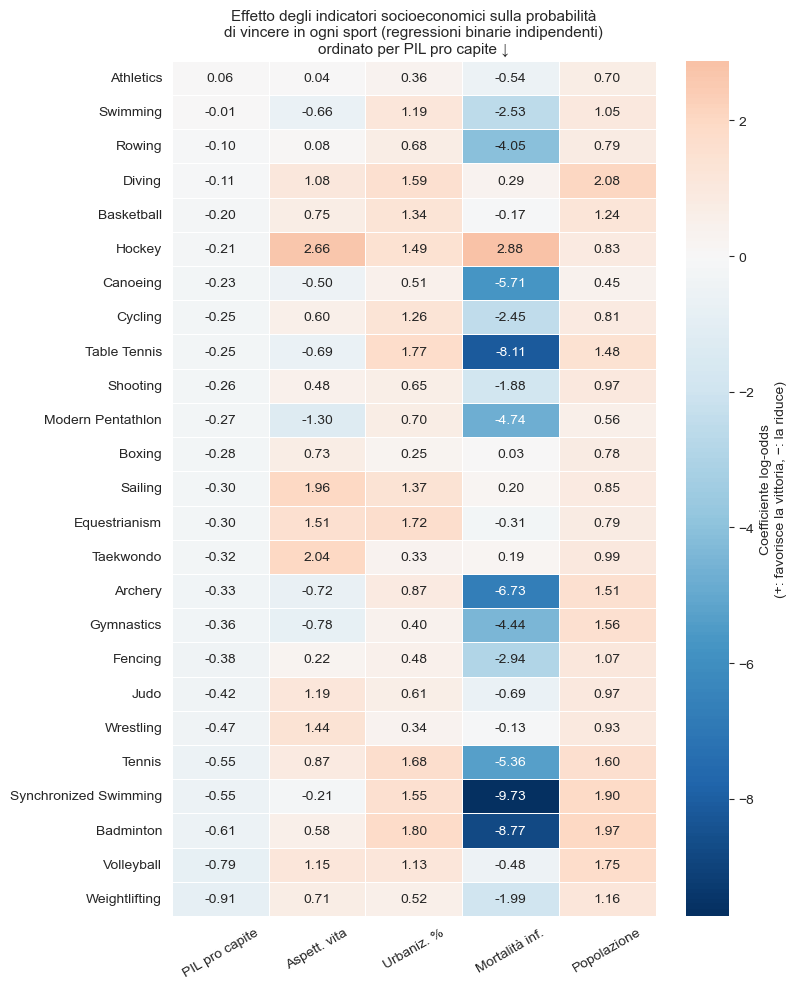

✓ Salvato: coeff_binarie.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    coef_matrix,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Coefficiente log-odds\n(+: favorisce la vittoria, −: la riduce)'}
)
ax.set_title(
    'Effetto degli indicatori socioeconomici sulla probabilità\n'
    'di vincere in ogni sport (regressioni binarie indipendenti)\n'
    'ordinato per PIL pro capite ↓',
    fontsize=11
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('coeff_binarie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: coeff_binarie.png")

In [17]:
# Bar chart orizzontale: un bar per sport, colore per AUC (affidabilità modello)
# Sport ordinati da "più favorito da PIL alto" a "più favorito da PIL basso"

gdp_sorted = results_df.sort_values('coef_gdp_per_capita', ascending=True)

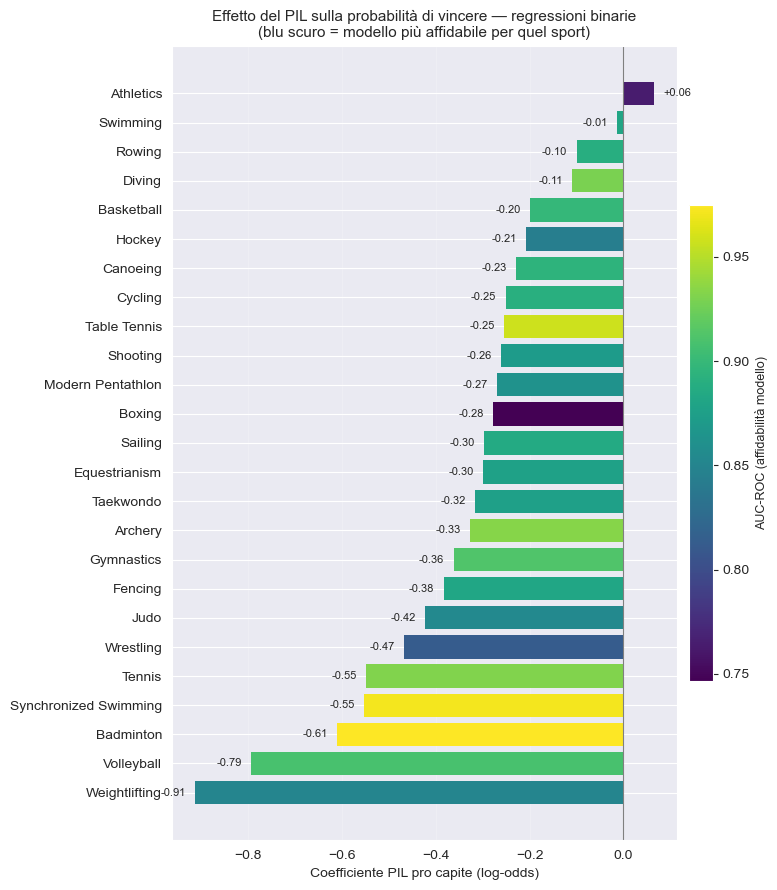

✓ Salvato: coeff_gdp_binarie.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 9))
norm = plt.Normalize(results_df['auc_mean'].min(), results_df['auc_mean'].max())
cmap = plt.cm.viridis
colors = [cmap(norm(v)) for v in gdp_sorted['auc_mean']]

bars = ax.barh(gdp_sorted['sport'], gdp_sorted['coef_gdp_per_capita'],
               color=colors, edgecolor='none')
ax.axvline(0, color='gray', linewidth=0.8)

# Colorbar per AUC
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('AUC-ROC (affidabilità modello)', fontsize=9)

# Etichette coefficiente
for bar, val in zip(bars, gdp_sorted['coef_gdp_per_capita']):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

ax.set_xlabel('Coefficiente PIL pro capite (log-odds)')
ax.set_title(
    'Effetto del PIL sulla probabilità di vincere — regressioni binarie\n'
    '(blu scuro = modello più affidabile per quel sport)',
    fontsize=11
)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('coeff_gdp_binarie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: coeff_gdp_binarie.png")

In [19]:
# Per ogni sport stimiamo la probabilità di vincere almeno una medaglia
# per i 4 profili paese che rappresentano i nostri cluster.

profiles = {
    'Ricchi avanzati\n(PIL 50k)':      [50000, 82, 88,  3, 50_000_000],
    'Reddito medio-alto\n(PIL 8k)':    [ 8000, 74, 65, 13, 30_000_000],
    'Reddito basso-medio\n(PIL 1.5k)': [ 1500, 65, 31, 38, 20_000_000],
    'Poveri estremi\n(PIL 900)':       [  900, 60, 36, 60, 15_000_000],
}

In [20]:
prob_records = []
for sport in SPORTS_OK:
    w = winners_by_sport[winners_by_sport['Sport'] == sport][['noc', 'year', 'won']]
    merged = country_year[['noc', 'year']].merge(w, on=['noc', 'year'], how='left')
    y = merged['won'].fillna(0).astype(int).values

    model = LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0,
                               class_weight='balanced', random_state=42)
    model.fit(X_sc, y)

    for profile_name, values in profiles.items():
        x = np.array(values).reshape(1, -1)
        x_imp = imp.transform(x)
        x_sc  = scaler.transform(x_imp)
        prob  = model.predict_proba(x_sc)[0][1]
        prob_records.append({
            'sport': sport, 'profile': profile_name, 'prob': prob * 100
        })

prob_df = pd.DataFrame(prob_records)
prob_pivot = prob_df.pivot(index='sport', columns='profile', values='prob')

In [21]:
# Ordiniamo per differenza tra ricchi e poveri (evidenzia gli sport più polarizzati)
profile_rich = [p for p in prob_pivot.columns if 'Ricchi' in p][0]
profile_poor = [p for p in prob_pivot.columns if 'Poveri' in p][0]
prob_pivot['gap'] = prob_pivot[profile_rich] - prob_pivot[profile_poor]
prob_pivot = prob_pivot.sort_values('gap', ascending=False).drop(columns='gap')

print("=== PROBABILITÀ PREDETTE DI VINCERE (%) ===")
print(prob_pivot.round(1).to_string())

=== PROBABILITÀ PREDETTE DI VINCERE (%) ===
profile                Poveri estremi\n(PIL 900)  Reddito basso-medio\n(PIL 1.5k)  Reddito medio-alto\n(PIL 8k)  Ricchi avanzati\n(PIL 50k)
sport                                                                                                                                      
Equestrianism                                1.4                              2.3                          50.6                        89.4
Sailing                                      2.4                              4.1                          55.6                        90.3
Rowing                                       0.8                              5.3                          61.3                        87.4
Tennis                                       0.0                              0.2                          41.9                        86.2
Cycling                                      1.0                              3.6                          57.5     

In [22]:
# Mostriamo i 10 sport con maggiore gap tra ricchi e poveri
# e i 5 sport più "equi" (gap minimo)

gap = (prob_pivot[profile_rich] - prob_pivot[profile_poor]).abs().sort_values(ascending=False)
top_polarized = gap.head(10).index.tolist()
top_equal     = gap.tail(5).index.tolist()
sports_plot   = top_polarized + top_equal

In [23]:
prob_plot = prob_pivot.loc[sports_plot]

In [25]:
profile_colors = ['#185FA5', '#3B6D11', '#BA7517', '#A32D2D']
profile_labels = [c.split('\n')[0] for c in prob_pivot.columns]

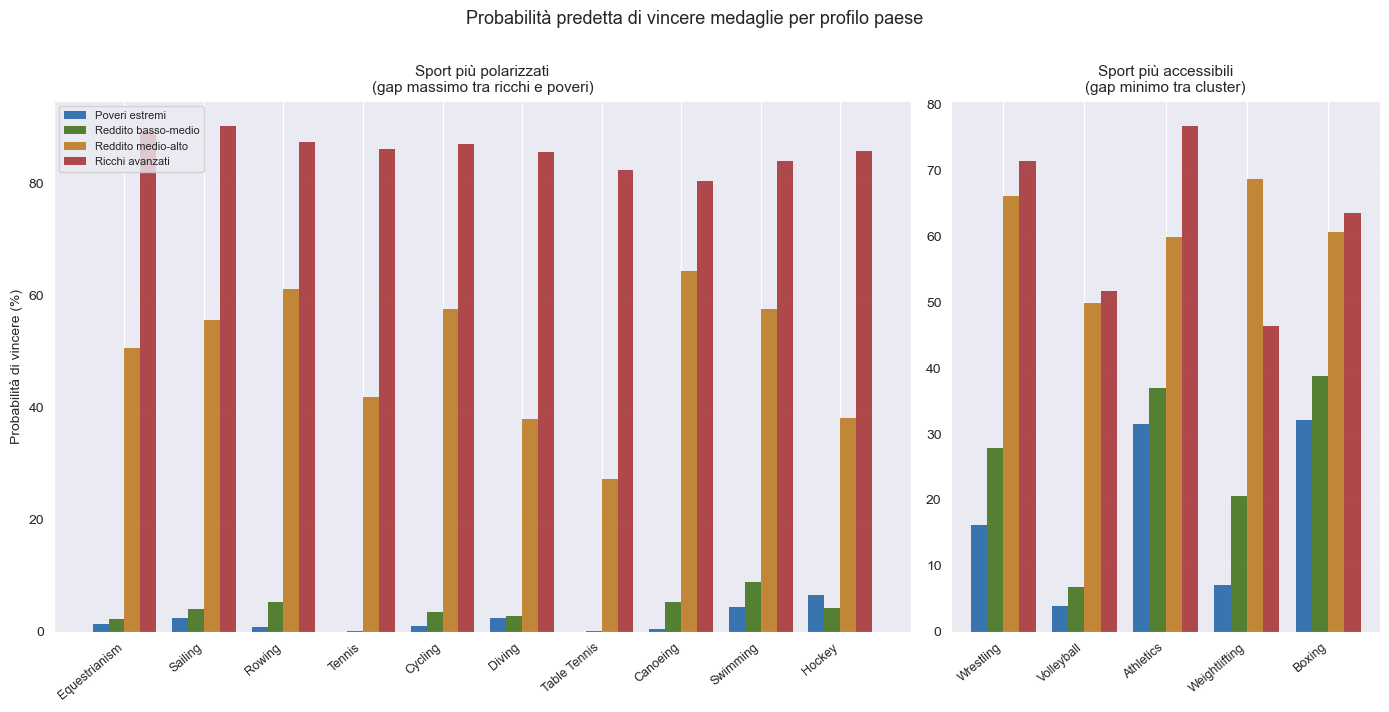

✓ Salvato: prob_predette_binarie.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7),
                          gridspec_kw={'width_ratios': [2, 1]})

# Pannello sinistro: sport più polarizzati
ax = axes[0]
x = np.arange(len(top_polarized))
w = 0.2
for i, (col, color) in enumerate(zip(prob_plot.columns, profile_colors)):
    label = col.split('\n')[0]
    ax.bar(x + i * w, prob_plot.loc[top_polarized, col],
           w, label=label, color=color, alpha=0.85, edgecolor='none')
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(top_polarized, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Probabilità di vincere (%)')
ax.set_title('Sport più polarizzati\n(gap massimo tra ricchi e poveri)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')

# Pannello destro: sport più equi
ax = axes[1]
x2 = np.arange(len(top_equal))
for i, (col, color) in enumerate(zip(prob_plot.columns, profile_colors)):
    ax.bar(x2 + i * w, prob_plot.loc[top_equal, col],
           w, color=color, alpha=0.85, edgecolor='none')
ax.set_xticks(x2 + w * 1.5)
ax.set_xticklabels(top_equal, rotation=40, ha='right', fontsize=9)
ax.set_title('Sport più accessibili\n(gap minimo tra cluster)', fontsize=11)
ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Probabilità predetta di vincere medaglie per profilo paese',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('prob_predette_binarie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: prob_predette_binarie.png")

In [27]:
print("=" * 60)
print("SINTESI RISULTATI — REGRESSIONI BINARIE")
print("=" * 60)
print()
print(f"Modelli addestrati: {len(SPORTS_OK)} (uno per sport)")
print(f"Osservazioni per modello: {len(country_year):,} paese-anno")
print(f"Metrica: AUC-ROC in cross-validation 5-fold")
print()

best = results_df.nlargest(5, 'auc_mean')[['sport','auc_mean','auc_std']]
worst = results_df.nsmallest(5, 'auc_mean')[['sport','auc_mean','auc_std']]
print("--- SPORT PIÙ PREDITTIBILI (AUC alto) ---")
for _, r in best.iterrows():
    print(f"  {r['sport']:<25} AUC={r['auc_mean']:.3f} ±{r['auc_std']:.3f}")
print()
print("--- SPORT MENO PREDITTIBILI (AUC basso) ---")
for _, r in worst.iterrows():
    print(f"  {r['sport']:<25} AUC={r['auc_mean']:.3f} ±{r['auc_std']:.3f}")
print()

rich_sports = results_df.nlargest(5, 'coef_gdp_per_capita')[['sport','coef_gdp_per_capita']]
poor_sports = results_df.nsmallest(5, 'coef_gdp_per_capita')[['sport','coef_gdp_per_capita']]
print("--- SPORT PIÙ FAVORITI DA PIL ALTO ---")
for _, r in rich_sports.iterrows():
    print(f"  {r['sport']:<25} β={r['coef_gdp_per_capita']:+.3f}")
print()
print("--- SPORT PIÙ FAVORITI DA PIL BASSO ---")
for _, r in poor_sports.iterrows():
    print(f"  {r['sport']:<25} β={r['coef_gdp_per_capita']:+.3f}")
print()
print("Nota metodologica:")
print("  β = coefficiente log-odds. Un β=+0.5 per il PIL nel nuoto significa")
print("  che all'aumentare di 1 deviazione standard del PIL, le probabilità")
print("  (in log-odds) di vincere nel nuoto aumentano di 0.5.")


SINTESI RISULTATI — REGRESSIONI BINARIE

Modelli addestrati: 25 (uno per sport)
Osservazioni per modello: 2,423 paese-anno
Metrica: AUC-ROC in cross-validation 5-fold

--- SPORT PIÙ PREDITTIBILI (AUC alto) ---
  Badminton                 AUC=0.975 ±0.017
  Synchronized Swimming     AUC=0.971 ±0.015
  Table Tennis              AUC=0.958 ±0.024
  Archery                   AUC=0.934 ±0.020
  Tennis                    AUC=0.932 ±0.027

--- SPORT MENO PREDITTIBILI (AUC basso) ---
  Boxing                    AUC=0.746 ±0.037
  Athletics                 AUC=0.764 ±0.031
  Wrestling                 AUC=0.812 ±0.016
  Hockey                    AUC=0.843 ±0.034
  Weightlifting             AUC=0.850 ±0.021

--- SPORT PIÙ FAVORITI DA PIL ALTO ---
  Athletics                 β=+0.065
  Swimming                  β=-0.013
  Rowing                    β=-0.099
  Diving                    β=-0.109
  Basketball                β=-0.199

--- SPORT PIÙ FAVORITI DA PIL BASSO ---
  Weightlifting             β